In [16]:
#import moduel
import numpy as np
import copy, math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
np.random.seed(2290) #400132290

In [17]:
#generate data
def func(x):
    
    return np.sin(2 * np.pi * x)

def generate_data(p):   
    #generate sets
    # X_train = np.linspace(0.,1.,p)
    # X_valid = np.linspace(0.,1.,p*10)
    X_train = np.linspace(0.,1.,9)
    X_valid = np.linspace(0.,1.,100)
    X_test = np.linspace(0.,1.,100)


    mean = 0
    variance = 0.04
    # noise = np.random.normal(mean, np.sqrt(variance), size=(10,))
    # t_train = func(X_train) + np.random.normal(mean, np.sqrt(variance), size=(p,))
    # t_valid = func(X_valid) + np.random.normal(mean, np.sqrt(variance), size=(p*10,))
    t_train = func(X_train) + np.random.normal(mean, np.sqrt(variance), size=(9,))
    t_valid = func(X_valid) + np.random.normal(mean, np.sqrt(variance), size=(100,))
    t_test = func(X_valid) + np.random.normal(mean, np.sqrt(variance), size=(100,))

    return X_train,X_valid,X_test,t_train,t_valid,t_test,

def generate_matrix(x_train,t_train,x_valid,t_valid,x_test,t_test,exp):
    xx_train = x_train[:,np.newaxis] ** [i for i in range(exp+1)]
    xx_valid = x_valid[:,np.newaxis] ** [i for i in range(exp+1)]
    xx_test = x_test[:,np.newaxis] ** [i for i in range(exp+1)]

    tt_train = t_train[:,np.newaxis]
    tt_valid = t_valid[:,np.newaxis]
    tt_test = t_test[:,np.newaxis]
    # tt_train = np.array(tt_train)
    # tt_valid = np.array(tt_valid)

    return xx_train,xx_valid,xx_test,tt_train,tt_valid,tt_test

#def apply_scaling():
    

In [18]:
#training model
def train(X, t_train):
    #w = (x^T * x)^-1 * (x^T * t)
    w = np.linalg.inv(X.T @ X) @ (X.T @ t_train)
    return w

def train_regularization(X,t_train,B):
    w = np.linalg.inv(X.T @ X + B) @ (X.T @ t_train)
    return w

def pred(X, w):
    pred = (w * X).sum(axis=1, keepdims=True)
    return pred

In [19]:
#calc error: apply equation provided in the lecture slides
def calc_error(w,x_train,t_train,x_valid,t_valid):
    # pred : w*x = y
    # (y - t)^T (y - t) N
    training_error = np.sum(np.square( (pred(x_train,w)- t_train) )) / t_train.shape[0]
    valid_error = np.sum(np.square( (pred(x_valid,w)- t_valid) )) / t_valid.shape[0]

    return training_error, valid_error

def calc_error_regulation(w, x_train, t_train, x_valid, t_valid, lamda):
    training_error, valid_error = calc_error(w, x_train, t_train, x_valid, t_valid)
    training_error += lamda * np.sum(np.square(w))
    valid_error += lamda * np.sum(np.square(w))

    return training_error,valid_error


In [20]:
#plot
def plot_data(idx, t_pred, x_train, t_train, x_valid, t_valid, reg=False):
    # create a new figure per model
    fig = plt.figure(idx)
    fig.suptitle(f"{'Lambda=' if reg else 'Degree '}{idx}")

    # plot the training and validation data
    plt.plot(x_train, t_train, '.', color="blue", label="Training data", mfc="none")
    plt.plot(x_valid, t_valid, '.', color="red", label="Validation data", mfc="none")

    # plot the model function and the true function
    plt.plot(x_valid, func(x_valid), color="black", label="f_true")
    plt.plot(x_valid, t_pred, color="lightgreen", label="f_pred")

    # label the axies
    plt.xlabel("x")
    plt.ylabel("t")
    
    # show the figure
    plt.legend(loc="best")
    plt.show(block=False)

def plot_error_curves(x, t_train_error, t_valid_error, x_valid, t_valid):
    # calculate average squared error between the targets and the true function
    # avg_sqr_err = np.sum(np.square( (func(x_valid)- t_valid) )) / t_valid.shape[0]
    avg_sqr_err = min(t_valid_error)
    ase_plot = [avg_sqr_err for i in range(len(x))]
    
    # create a new figure per model
    fig = plt.figure()
    fig.suptitle(f"Errors")

    # plot the training and validation data
    plt.plot(x, t_train_error, '-', color="blue", label="Training data", mfc="none")
    plt.plot(x, t_valid_error, '-', color="red", label="Validation data", mfc="none")
    plt.plot(x, ase_plot, '-', color="yellow", label="f_opt RMSE", mfc="none")
    plt.xlabel("M")
    plt.ylabel("RMSE")

    # show the figure
    plt.legend(loc="best")
    plt.show(block=False)

    #the average squared error between the targets and the true function ftrue(x) for the examples in the validation set
    

w = [0.04510446]
Degree 0: training error =     0.4594855711110662, validation error = 0.4808131526815494
w = [ 0.72466292 -1.35911692]
Degree 1: training error =     0.2670690279528758, validation error = 0.21708840492403414
w = [ 0.74305116 -1.48520773  0.12609081]
Degree 2: training error =     0.2669361921642164, validation error = 0.21645917912839252
w = [  0.09485645   9.68843454 -29.5056677   19.75450567]
Degree 3: training error =   0.031134135669558565, validation error = 0.04912038919479394
w = [  0.19818316   5.39791568  -7.58072268 -15.51434664  17.63442615]
Degree 4: training error =     0.0190172574409248, validation error = 0.055788711231809035
w = [   0.24460112    0.20529333   36.23783065 -139.79069564  160.23039632
  -57.03838807]
Degree 5: training error =   0.012014719945048019, validation error = 0.048532229953551276
w = [   0.24270869    0.95318131   26.99571148 -100.0648236    83.52393609
   11.17384099  -22.73740969]
Degree 6: training error =   0.01196547723605

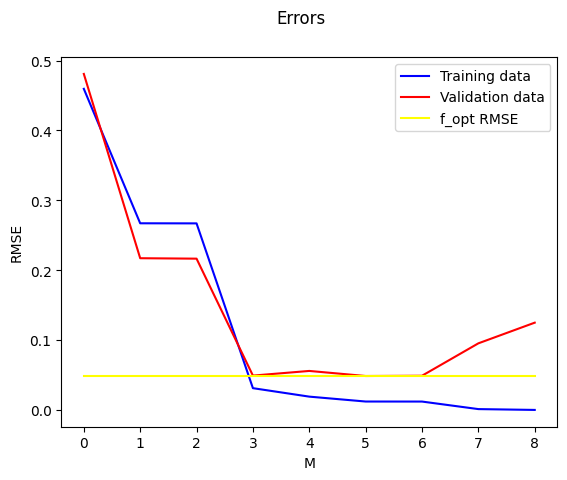

[0.4594855711110662, 0.2670690279528758, 0.2669361921642164, 0.031134135669558565, 0.0190172574409248, 0.012014719945048019, 0.011965477236059707, 0.001173305017792628, 1.4531978978887448e-11]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]
w1e-14 = [ 4.51044579e-02 -1.93776667e-01  4.40440684e+01 -4.75569175e+02
  2.30110961e+03 -5.84947559e+03  7.98065811e+03 -5.52227315e+03
  1.52151666e+03]
w1e-13 = [ 4.51044579e-02 -8.06914803e-02  4.17852765e+01 -4.59238329e+02
  2.24178556e+03 -5.72943000e+03  7.84338472e+03 -5.43935113e+03
  1.50096145e+03]
w1e-12 = [ 4.51044579e-02  8.56414758e-01  2.30656027e+01 -3.23888153e+02
  1.75007834e+03 -4.73437932e+03  6.70548030e+03 -4.75195505e+03
  1.33055955e+03]
w1e-11 = [ 4.51044579e-02  3.96732797e+00 -3.91274062e+01  1.26140642e+02
  1.14013156e+02 -1.42140257e+03  2.91474087e+03 -2.46088624e+03
  7.62374594e+02]
w1e-10 = [ 4.51044579e-02  5.55993569e+00 -7.16519242e+01  3.66330611e+02
 -7.75432545e+02  4.09049604e+02  7.90867621e+02 -1.16178228e+03
  4.3688000

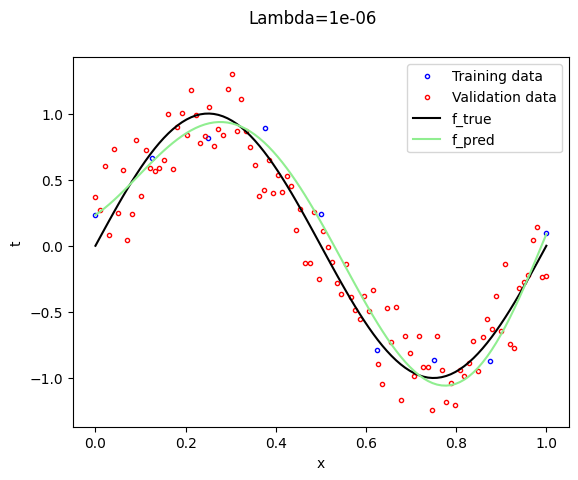

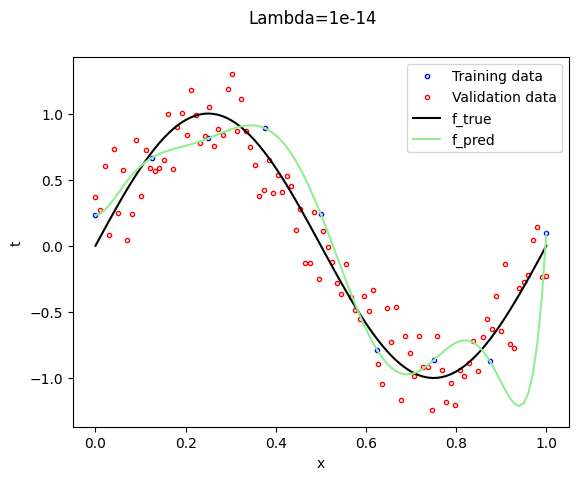

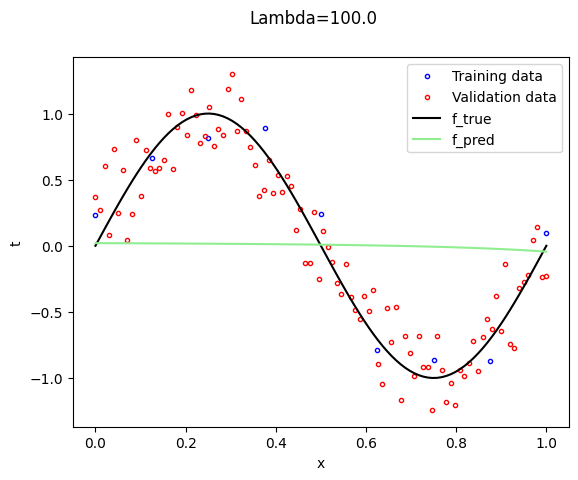

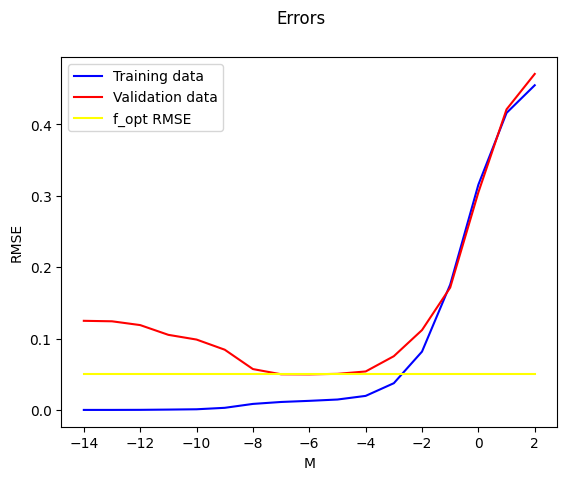

In [21]:
# degree #
p = 9
# generate data
x_train,x_valid,x_test,t_train,t_valid,t_test = generate_data(p)

# create a dictionary to store the answers
ans = {
    "M": [ i for i in range(0,p)],
    "training_error" : [],
    "valid_error" : []
}

# repeat until degree p
for exp in ans["M"]:

    xx_train,xx_valid,xx_test,tt_train,tt_valid,tt_test = generate_matrix(x_train,t_train,x_valid,t_valid,x_test,t_test,exp)
    w = train(xx_train,t_train)
    print(f"w = {w}")
    train_error, valid_error = calc_error(w,xx_train,tt_train,xx_valid,tt_valid)
    print(f"Degree {exp}: training error = {train_error:22}, validation error = {valid_error}")
    ans["training_error"].append(train_error)
    ans["valid_error"].append(valid_error)
    # plot_data(exp, pred(w, xx_valid), x_train, t_train, x_valid, t_valid)

print(f"The lowest training error was at degree {ans['M'][np.argmin(ans['training_error'])]} and the "
          f"lowest validation error was at degree {ans['M'][np.argmin(ans['valid_error'])]}")

plot_error_curves(ans["M"],ans["training_error"],ans["valid_error"],x_valid,t_valid)
print(ans["training_error"])

print(xx_train[-1,:])
# apply regulation
xx_train = np.delete(xx_train,0,1)
xx_valid = np.delete(xx_valid,0,1)
xx_test = np.delete(xx_test,0,1)

# apply scaling
sc = StandardScaler()
xx_train = sc.fit_transform(xx_train)
xx_valid = sc.transform(xx_valid)
xx_test = sc.transform(xx_test)
xx_train = np.c_[np.ones(t_train.shape[0]), xx_train]
xx_valid = np.c_[np.ones(t_valid.shape[0]), xx_valid]
xx_test = np.c_[np.ones(t_test.shape[0]), xx_test]


# store the results for regression with regulation 
regularization = {
    # "lamda" : np.exp([i for i in range(-100,-1)]).tolist(),
    "lamda" : (10.0 ** np.arange(-14, 3)).tolist(),
    "training_error" : [],
    "valid_error" : [],
    "w" : []
}

# calculate the error for all lambda value for when degree is p, 
for lamda in regularization["lamda"]:
    #create lambda
    B = np.zeros((p,p))
    np.fill_diagonal(B, lamda * t_train.shape[0])

    w = train_regularization(xx_train,t_train,B)
    print(f"w{lamda} = {w}")
    regularization["w"].append(w)
    train_error, valid_error = calc_error_regulation(w,xx_train,tt_train,xx_valid,tt_valid,lamda)
    
    #print(f"lamda: {lamda}: training error = {train_error:22}, validation error = {valid_error}")
    regularization["training_error"].append(train_error) 
    regularization["valid_error"].append(valid_error)

# find the smallest valid error
lowest_valid_error = np.argmin(regularization["valid_error"])

# store value
lambda1 = regularization['lamda'][lowest_valid_error]
# any large value of lambda works
lambda2 = regularization['lamda'][0]
lambda3 = regularization['lamda'][-1]

print(f"The lowest regularised validation error was at constant {lambda1}")

plot_data(lambda1, pred(regularization["w"][lowest_valid_error], xx_valid), x_train, t_train, x_valid,
              t_valid, reg=True)
plot_data(lambda2, pred(regularization["w"][1], xx_valid), x_train, t_train, x_valid, t_valid,
              reg=True)
plot_data(lambda3, pred(regularization["w"][-1], xx_valid), x_train, t_train, x_valid, t_valid,
              reg=True)


plot_error_curves(np.arange(-14, 3).tolist(),regularization["training_error"],regularization["valid_error"],x_valid,t_valid)


In [22]:
min(regularization["valid_error"])

0.04976173312476522

In [23]:
min(regularization["training_error"])

1.365087250591506e-06

In [30]:
train_error, test_error = calc_error_regulation(regularization["w"][8],xx_train,tt_train,xx_test,tt_test,1e-06)
test_error

0.058551939666690235

In [31]:
print("λ\t\tTraining RMSE\tValidation RMSE")
print("-" * 45)

for lam, tr_err, val_err in zip(
        regularization["lamda"],
        regularization["training_error"],
        regularization["valid_error"]):
    print(f"{lam:.1e}\t{tr_err:.6f}\t{val_err:.6f}")

λ		Training RMSE	Validation RMSE
---------------------------------------------
1.0e-14	0.000001	0.124796
1.0e-13	0.000013	0.124115
1.0e-12	0.000114	0.118801
1.0e-11	0.000466	0.105144
1.0e-10	0.000905	0.098542
1.0e-09	0.002947	0.084331
1.0e-08	0.008420	0.057218
1.0e-07	0.011135	0.049918
1.0e-06	0.012712	0.049762
1.0e-05	0.014569	0.050537
1.0e-04	0.019656	0.053847
1.0e-03	0.037415	0.075241
1.0e-02	0.081666	0.111822
1.0e-01	0.175489	0.171313
1.0e+00	0.315426	0.304670
1.0e+01	0.415947	0.420931
1.0e+02	0.454701	0.470555
